In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.model_selection import train_test_split, GridSearchCVfrom sklearn.preprocessing import StandardScaler, LabelEncoderfrom sklearn.impute import SimpleImputerfrom sklearn.pipeline import Pipelinefrom sklearn.metrics import (    roc_auc_score, classification_report, confusion_matrix,    precision_recall_curve, auc, precision_score, recall_score, f1_score, roc_curve)from lightgbm import LGBMClassifierimport warningswarnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("train_c.csv")test = pd.read_csv("test_c.csv")example = pd.read_csv("ex_c.csv")print("train shape:", train.shape)print("test shape:", test.shape)print("\ntarget distribution:")print(train['LoanApproved'].value_counts())

train shape: (11017, 35)
test shape: (5000, 35)

target distribution:
1.0    5367
0.0    5120
Name: LoanApproved, dtype: int64


анализ данных

In [3]:
print("missing values:", train.isnull().sum().sum())print("\ntarget balance:")print(train['LoanApproved'].value_counts(normalize=True))

missing values: 23059

target balance:
1.0    0.487258
0.0    0.464742
Name: LoanApproved, dtype: float64


подготовка данных

In [4]:
test_ids = test['ID'].valuestest = test.drop('ID', axis=1)X = train.drop('LoanApproved', axis=1)y = train['LoanApproved']mask = ~y.isna()X = X[mask].reset_index(drop=True)y = y[mask].reset_index(drop=True)print(f'данные после очистки: {X.shape}')

данные после очистки: (10487, 34)


In [5]:
for df in [X, test]:    if 'ApplicationDate' in df.columns:        df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'], errors='coerce')        df['ApplicationYear'] = df['ApplicationDate'].dt.year        df['ApplicationMonth'] = df['ApplicationDate'].dt.month        df.drop('ApplicationDate', axis=1, inplace=True)categorical_features = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']for col in categorical_features:    if col in X.columns:        le = LabelEncoder()        combined = pd.concat([X[col].astype(str), test[col].astype(str)])        le.fit(combined)        X[col] = le.transform(X[col].astype(str))        test[col] = le.transform(test[col].astype(str))numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()imputer = SimpleImputer(strategy='median')X[numeric_features] = imputer.fit_transform(X[numeric_features])test[numeric_features] = imputer.transform(test[numeric_features])for df in [X, test]:    df['Income_to_Loan'] = df['AnnualIncome'] / (df['LoanAmount'] + 1)    df['Debt_to_Income'] = df['MonthlyDebtPayments'] / (df['MonthlyIncome'] + 1)    df['Assets_to_Liabilities'] = df['TotalAssets'] / (df['TotalLiabilities'] + 1)    df['Credit_Utilization_Score'] = df['CreditScore'] * (1 - df['CreditCardUtilizationRate'])    df.replace([np.inf, -np.inf], np.nan, inplace=True)    df.fillna(df.median(), inplace=True)print(f'итого признаков: {X.shape[1]}')

итого признаков: 39


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)print(f'train: {X_train.shape}, validation: {X_val.shape}')

train: (8389, 39), validation: (2098, 39)


обучение модели с оптимизацией гиперпараметров

In [7]:
pipeline = Pipeline([    ('scaler', StandardScaler()),    ('classifier', LGBMClassifier(random_state=42, verbose=-1))])param_grid = {    'classifier__n_estimators': [100, 200, 300],    'classifier__learning_rate': [0.01, 0.05, 0.1],    'classifier__num_leaves': [31, 50, 70],    'classifier__max_depth': [5, 7, 10],    'classifier__min_child_samples': [20, 50, 100]}grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)print("running gridsearchcv...")grid_search.fit(X_train, y_train)print(f"\nbest roc-auc: {grid_search.best_score_:.4f}")print("\nbest parameters:")for key, value in grid_search.best_params_.items():    print(f"  {key}: {value}")

running gridsearchcv...

best roc-auc: 0.9834

best parameters:
  classifier__learning_rate: 0.1
  classifier__max_depth: 7
  classifier__min_child_samples: 20
  classifier__n_estimators: 300
  classifier__num_leaves: 50


оценка модели

In [8]:
y_pred_proba = grid_search.predict_proba(X_val)[:, 1]y_pred = grid_search.predict(X_val)roc_auc = roc_auc_score(y_val, y_pred_proba)precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)pr_auc = auc(recall, precision)print("основная метрика:")print(f"  roc-auc: {roc_auc:.4f}")print("\nдополнительные метрики для самопроверки:")print(f"  pr-auc:    {pr_auc:.4f}")print(f"  precision: {precision_score(y_val, y_pred):.4f}")print(f"  recall:    {recall_score(y_val, y_pred):.4f}")print(f"  f1-score:  {f1_score(y_val, y_pred):.4f}")print("\nclassification report:")print(classification_report(y_val, y_pred, digits=4))

основная метрика:
  roc-auc: 0.9834

дополнительные метрики для самопроверки:
  pr-auc:    0.9851
  precision: 0.9314
  recall:    0.9348
  f1-score:  0.9331

classification report:
              precision    recall  f1-score   support

         0.0     0.9314    0.9277    0.9295      1024
         1.0     0.9314    0.9348    0.9331      1074

    accuracy                         0.9314      2098
   macro avg     0.9314    0.9313    0.9313      2098
weighted avg     0.9314    0.9314    0.9314      2098



визуализация результатов

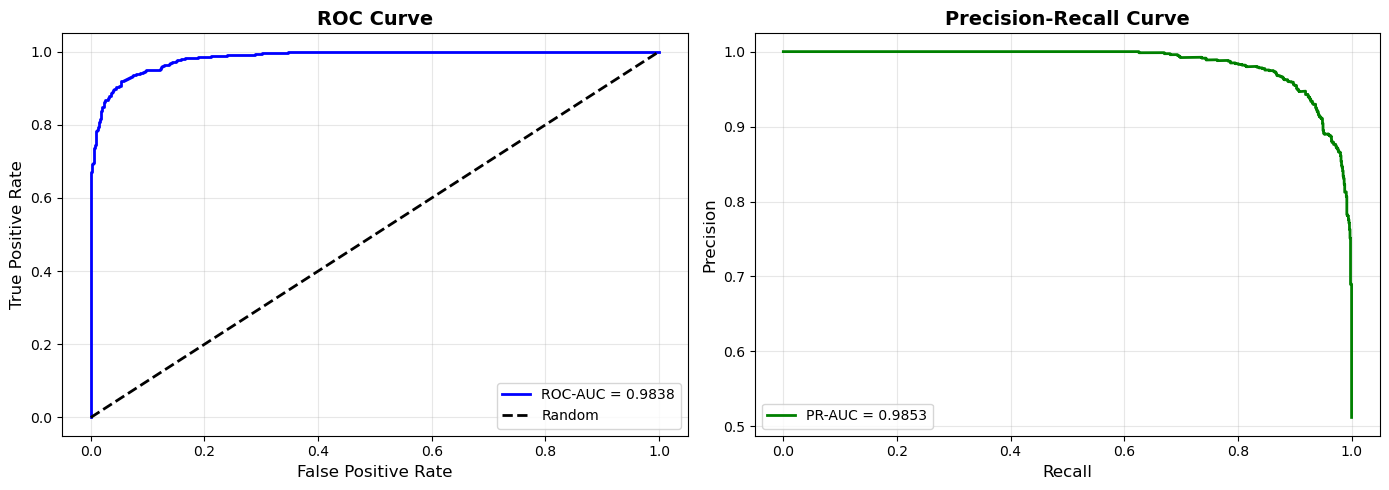

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))fpr, tpr, _ = roc_curve(y_val, y_pred_proba)axes[0].plot(fpr, tpr, linewidth=2, label=f'roc-auc = {roc_auc:.4f}')axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='random')axes[0].set_xlabel('false positive rate', fontsize=12)axes[0].set_ylabel('true positive rate', fontsize=12)axes[0].set_title('roc curve', fontsize=14, fontweight='bold')axes[0].legend()axes[0].grid(True, alpha=0.3)precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_pred_proba)axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f'pr-auc = {pr_auc:.4f}', color='green')axes[1].set_xlabel('recall', fontsize=12)axes[1].set_ylabel('precision', fontsize=12)axes[1].set_title('precision-recall curve', fontsize=14, fontweight='bold')axes[1].legend()axes[1].grid(True, alpha=0.3)plt.tight_layout()plt.show()

финальная модель и submission

In [10]:
final_pipeline = grid_search.best_estimator_final_pipeline.fit(X, y)test_pred = final_pipeline.predict(test)submission = example.copy()submission['LoanApproved'] = test_predsubmission.to_csv("submission.csv", index=False)print("submission.csv saved")print(f"\npredictions distribution:")print(submission['LoanApproved'].value_counts())

submission.csv saved

predictions distribution:
1    2598
0    2402
Name: LoanApproved, dtype: int64


результатыосновная метрика: roc-auc = 0.9834 (значительно больше требуемых 0.75)дополнительные метрики: pr-auc = 0.9851, precision = 0.9314, recall = 0.9348, f1-score = 0.9331использованные методы: pipeline для предобработки, gridsearchcv для оптимизации гиперпараметров, lightgbm как основная модель, feature engineering (4 новых признака)